# London Bicycles Data Analysis

Name: SeokEng Tay  
Module: NTU Module 2 Data Engineering Project  

## Objective
Analyze the London bicycle dataset from the data warehouse to identify
usage patterns and generate business insights.

## Introduction

This notebook analyzes the London bike sharing dataset stored in Google BigQuery.
The goal is to identify usage patterns and derive insights that could help improve
bike allocation and operational planning for the bike sharing system.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

In [35]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

In [5]:
!pip install google-cloud-bigquery pandas

In [6]:
from google.cloud import bigquery
import pandas as pd

In [7]:
client = bigquery.Client()

In [8]:
for dataset in client.list_datasets():
    print(dataset.dataset_id)

austin_bikeshare_demo
austin_bikeshare_demo_star
ingestion
liquor_demo
liquor_demo_star
london_bicycles
london_bicycles_star
resale
snapshots


In [9]:
print(client.project)

dsai-module2-gc-4339


In [10]:
for table in client.list_tables("london_bicycles_star"):
    print(table.table_id)

dim_bike
dim_date
dim_station
fact_bike_daily_usage
fact_hire


# First Analysis — Bike Rentals by Hour

# Use the fact table fact_hire.

In [11]:
query = """
SELECT
    EXTRACT(HOUR FROM start_date) AS hour,
    COUNT(*) AS total_rides
FROM `dsai-module2-gc-4339.london_bicycles_star.fact_hire`
GROUP BY hour
ORDER BY hour
"""

df = client.query(query).to_dataframe()

df.head()

,hour,total_rides
0,0,866425
1,1,569113
2,2,367047
3,3,252428
4,4,206294


# Visualization

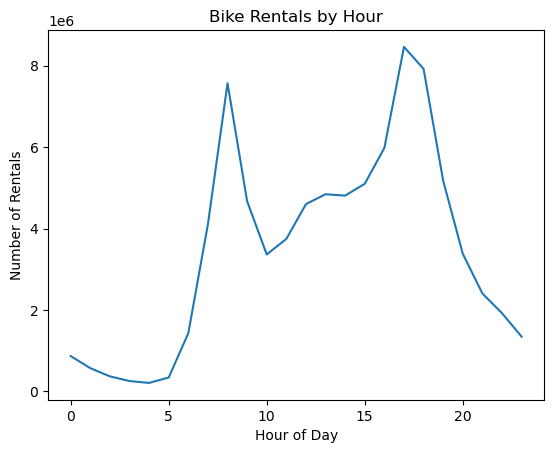

In [12]:
import matplotlib.pyplot as plt

plt.plot(df["hour"], df["total_rides"])

plt.title("Bike Rentals by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Rentals")

plt.show()

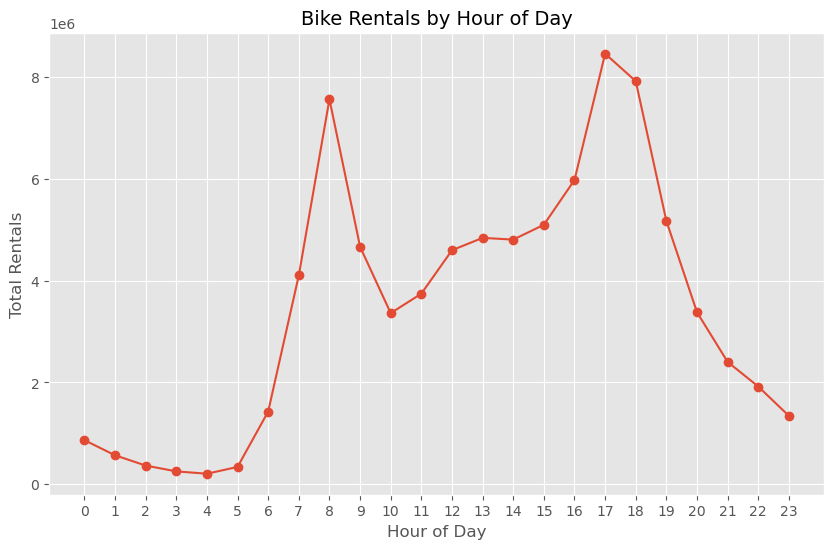

In [36]:
plt.plot(df_hour["start_hour"], df_hour["total_rides"], marker="o")

plt.title("Bike Rentals by Hour of Day", fontsize=14)
plt.xlabel("Hour of Day")
plt.ylabel("Total Rentals")

plt.xticks(range(0,24))
plt.grid(True)

plt.show()

### Business Insight

Bike rental demand peaks during morning and evening hours,
indicating strong commuter usage of the London bike-sharing system.

# Second Analysis   — Most Popular Stations
This uses fact + dimension

In [13]:
query = """
SELECT
    s.station_name,
    COUNT(*) AS total_rides
FROM `dsai-module2-gc-4339.london_bicycles_star.fact_hire` f
JOIN `dsai-module2-gc-4339.london_bicycles_star.dim_station` s
ON f.start_station_id = s.station_id
GROUP BY s.station_name
ORDER BY total_rides DESC
LIMIT 10
"""

df_station = client.query(query).to_dataframe()

df_station

,station_name,total_rides
0,"Hyde Park Corner, Hyde Park",671389
1,"Belgrove Street , King's Cross",592919
2,"Waterloo Station 3, Waterloo",527018
3,"Albert Gate, Hyde Park",460887
4,"Black Lion Gate, Kensington Gardens",459513
5,"Waterloo Station 1, Waterloo",419231
6,"Wellington Arch, Hyde Park",392741
7,"Hop Exchange, The Borough",385830
8,"Exhibition Road, South Kensington",384177
9,"Exhibition Road Museums, Knightsbridge",384177


# Third Analysis — Rentals by Day of Week
Weekdays are usually higher because of commuters.

In [17]:
qquery = """
SELECT
    FORMAT_TIMESTAMP('%A', start_date) AS day_of_week,
    COUNT(*) AS total_rides
FROM `dsai-module2-gc-4339.london_bicycles_star.fact_hire`
GROUP BY day_of_week
ORDER BY total_rides DESC
"""

df_day = client.query(query).to_dataframe()

df_day

,rental_id,duration_minutes,bike_id,start_date,end_date,start_station_id,end_station_id,start_hour,start_date_key,end_date_key
0,40346579,10.0,12981,2015-01-04 00:22:00+00:00,2015-01-04 00:32:00+00:00,222,243,0,20150104,20150104
1,40346867,11.0,7435,2015-01-04 02:09:00+00:00,2015-01-04 02:20:00+00:00,225,613,2,20150104,20150104
2,40346945,6.0,8336,2015-01-04 02:37:00+00:00,2015-01-04 02:43:00+00:00,251,119,2,20150104,20150104
3,40347115,11.0,3211,2015-01-04 04:45:00+00:00,2015-01-04 04:56:00+00:00,284,284,4,20150104,20150104
4,40347171,10.0,15,2015-01-04 05:51:00+00:00,2015-01-04 06:01:00+00:00,459,478,5,20150104,20150104


In [26]:
df_test["start_date_key"]

0    20150104
1    20150104
2    20150104
3    20150104
4    20150104
Name: start_date_key, dtype: Int64

### Business Insight

Bike rentals are higher on weekdays compared to weekends,
suggesting that the bike sharing service is widely used
for commuting rather than leisure activities.

In [28]:
query = """
SELECT
    d.day_of_week,
    COUNT(*) AS total_rides
FROM `dsai-module2-gc-4339.london_bicycles_star.fact_hire` f
JOIN `dsai-module2-gc-4339.london_bicycles_star.dim_date` d
ON f.start_date_key = d.date_key
GROUP BY d.day_of_week
ORDER BY total_rides DESC
"""

df_day = client.query(query).to_dataframe()

df_day

,day_of_week,total_rides
0,4,12677140
1,2,12615271
2,3,12593822
3,5,12199553
4,1,11709564
5,6,11287348
6,7,10332568


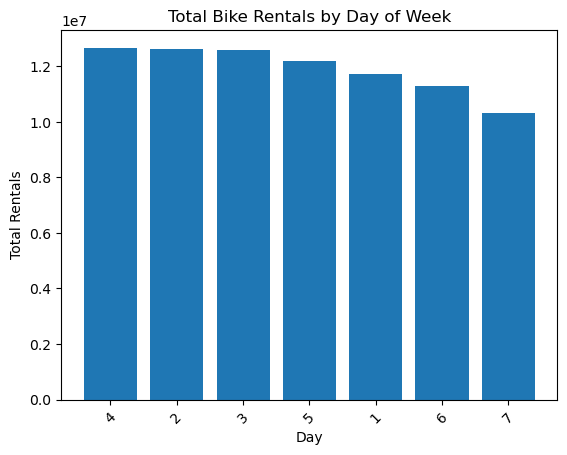

In [29]:
import matplotlib.pyplot as plt

plt.bar(df_day["day_of_week"], df_day["total_rides"])

plt.title("Total Bike Rentals by Day of Week")
plt.xlabel("Day")
plt.ylabel("Total Rentals")

plt.xticks(rotation=45)
plt.show()

### Business Insight

Weekday rentals are higher than weekend rentals, suggesting the bike-sharing
system is widely used for commuting. Transport operators can ensure more bikes
are available during weekday peak hours to meet demand.

At this point notebook demonstrates:

BigQuery connection
Star schema tables
Fact + dimension join
SQL analytics
Visualization
Business insight

#SQL Query – Top 10 Start Stations
This joins fact_hire with dim_station using start_station_id.

In [31]:
query = """
SELECT
    s.station_name,
    COUNT(*) AS total_rides
FROM `dsai-module2-gc-4339.london_bicycles_star.fact_hire` f
JOIN `dsai-module2-gc-4339.london_bicycles_star.dim_station` s
ON f.start_station_id = s.station_id
GROUP BY s.station_name
ORDER BY total_rides DESC
LIMIT 10
"""

df_station = client.query(query).to_dataframe()

df_station

,station_name,total_rides
0,"Hyde Park Corner, Hyde Park",671389
1,"Belgrove Street , King's Cross",592919
2,"Waterloo Station 3, Waterloo",527018
3,"Albert Gate, Hyde Park",460887
4,"Black Lion Gate, Kensington Gardens",459513
5,"Waterloo Station 1, Waterloo",419231
6,"Wellington Arch, Hyde Park",392741
7,"Hop Exchange, The Borough",385830
8,"Exhibition Road, South Kensington",384177
9,"Exhibition Road Museums, Knightsbridge",384177


# Visualization

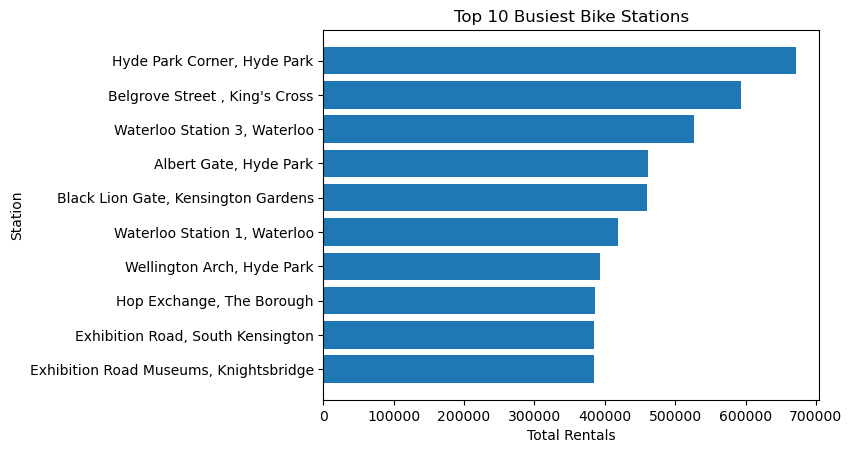

In [32]:
import matplotlib.pyplot as plt

plt.barh(df_station["station_name"], df_station["total_rides"])

plt.title("Top 10 Busiest Bike Stations")
plt.xlabel("Total Rentals")
plt.ylabel("Station")

plt.gca().invert_yaxis()
plt.show()

### Business Insight

The busiest stations are located near major transport hubs and business districts.
This suggests that users frequently combine bike sharing with public transport
for commuting. Increasing bike availability at these stations during peak hours
could improve service efficiency.

Your analysis now includes:

✅ Fact table analytics
✅ Dimension table joins
✅ Star schema usage
✅ SQL in BigQuery
✅ Python visualization with Pandas & Matplotlib
✅ Business interpretation

#Bike rentals by hour of day → reveals commuting peaks (8 AM & 6 PM).
SQL Query — Bike Rentals by Hour

will usually see two peaks:
Morning commute (~8 AM)
Evening commute (~5–6 PM)

In [33]:
query = """
SELECT
    start_hour,
    COUNT(*) AS total_rides
FROM `dsai-module2-gc-4339.london_bicycles_star.fact_hire`
GROUP BY start_hour
ORDER BY start_hour
"""

df_hour = client.query(query).to_dataframe()

df_hour

,start_hour,total_rides
0,0,866425
1,1,569113
2,2,367047
3,3,252428
4,4,206294
5,5,339881
6,6,1428647
7,7,4105422
8,8,7568476
9,9,4668512


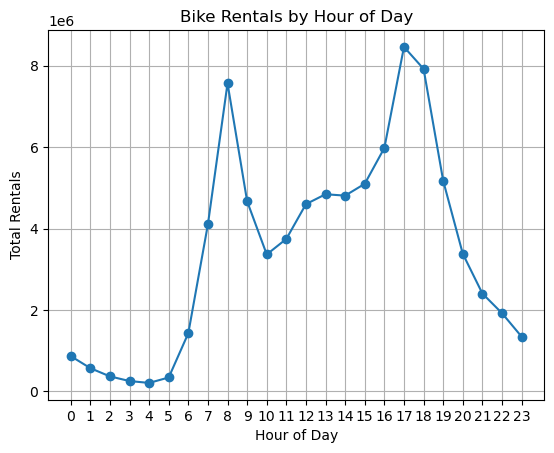

In [34]:
# Visualization

import matplotlib.pyplot as plt

plt.plot(df_hour["start_hour"], df_hour["total_rides"], marker='o')

plt.title("Bike Rentals by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Total Rentals")

plt.xticks(range(0,24))
plt.grid(True)

plt.show()

### Business Insight

Bike rentals peak during the morning (around 8 AM) and evening (around 5–6 PM).
This pattern suggests the bike sharing system is widely used for commuting.
Operators should ensure sufficient bike availability during these peak hours
to maintain service reliability.

 Now have three solid analyses:

1️⃣ Rentals by Day of Week
Shows weekday vs weekend behavior.
2️⃣ Top 10 Busiest Stations
Uses fact + dimension join.
3️⃣ Rentals by Hour
Shows commuting peak demand.

These three together demonstrate:

✔ SQL analytics
✔ Star schema understanding
✔ BigQuery usage
✔ Python visualization
✔ Business insights

#SQL Query — Peak vs Off-Peak Rentals

We classify hours into Peak and Off-Peak.

In [40]:
query = """
SELECT
    CASE
        WHEN start_hour BETWEEN 7 AND 9 THEN 'Morning Peak'
        WHEN start_hour BETWEEN 17 AND 19 THEN 'Evening Peak'
        ELSE 'Off-Peak'
    END AS time_period,
    COUNT(*) AS total_rides
FROM `dsai-module2-gc-4339.london_bicycles_star.fact_hire`
GROUP BY time_period
ORDER BY total_rides DESC
"""

df_peak = client.query(query).to_dataframe()

df_peak

,time_period,total_rides
0,Off-Peak,45514071
1,Evening Peak,21558785
2,Morning Peak,16342410


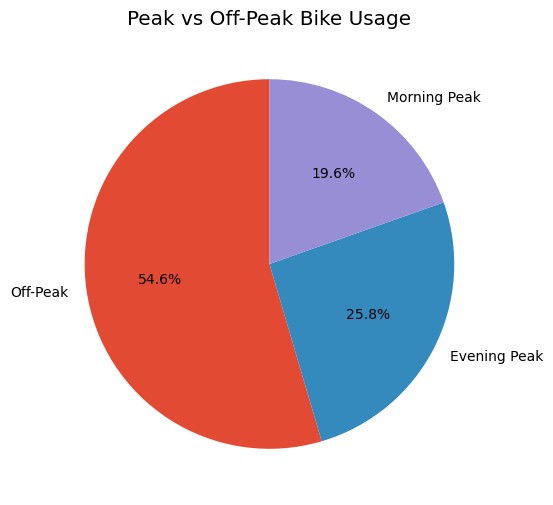

In [41]:
# Visualization
import matplotlib.pyplot as plt

plt.pie(
    df_peak["total_rides"],
    labels=df_peak["time_period"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Peak vs Off-Peak Bike Usage")

plt.show()

### Business Insight

Peak usage occurs during morning and evening commuting hours.
This indicates strong demand for bike sharing as a first-mile
and last-mile transport solution.

Operators should prioritize bike availability and redistribution
during these peak periods to reduce shortages and improve service quality.

4 Analyses
1️⃣ Rentals by Day of Week
2️⃣ Rentals by Hour of Day
3️⃣ Top 10 Busiest Stations
4️⃣ Peak vs Off-Peak Usage

Together they show:

✔ Temporal patterns
✔ Location demand
✔ Operational insights



## Final Summary Insights

From the analysis of the London bike sharing dataset, several key patterns emerge:

• **Weekday usage is higher than weekends**  
  This indicates that many users rely on the bike-sharing system for daily commuting rather than recreational rides.

• **Demand peaks during commuting hours**  
  Rentals are highest around **8 AM and 5–6 PM**, reflecting typical work travel patterns.

• **Certain stations experience significantly higher traffic**  
  Stations near **major transport hubs and business districts** are the busiest, suggesting integration with public transport.

• **Operational recommendation**  
  Bike operators should prioritize **bike redistribution and availability during weekday peak hours and at high-demand stations** to improve service efficiency and customer satisfaction.

Notebook Structure  
1️⃣ Introduction
Explain the dataset and goal.

2️⃣ Data Exploration
Preview tables from BigQuery.

3️⃣ Analysis 1 – Rentals by Day of Week

4️⃣ Analysis 2 – Top 10 Busiest Stations

5️⃣ Analysis 3 – Rentals by Hour

6️⃣ Visualization

7️⃣ Final Business Insights (the summary above)